'Decoy' run to remove variable initialization from time equation:

Best-Case, Already Sorted Arrays:

6
Execution time on 5 elements   =  3.944600007343979 

6
Execution time on 5 elements   =  1.3820000049236114 

6
Execution time on 10 elements   =  0.9173999842460034 

8
Execution time on 15 elements   =  0.9399999953529914 

10
Execution time on 20 elements   =  1.0735999921962502 


Worst-Case, Reverse Sorted Arrays:

6
Execution time on 5 elements   =  0.5830999953104765 

6
Execution time on 10 elements   =  0.6297000027188915 

8
Execution time on 15 elements   =  0.8116999879348441 

10
Execution time on 20 elements   =  1.385900009154284 


Generating plot...


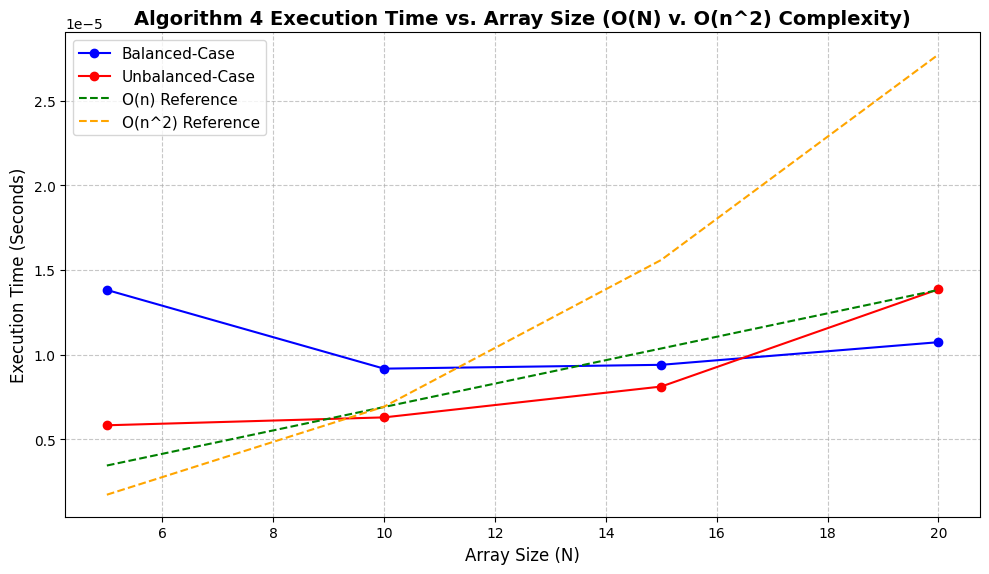

In [ ]:
"""
Anonymous Algorithm 4
Randomized Quickselect

Victor Morgan and Ahmed Abdallah
04/24/2026

This algorithm implements the Randomized Quickselect algorithm to find the median
(or more generally, the i-th order statistic) of an array.The algorithm repeatedly
selects a random pivot and partitions the array such that elements smaller than
the pivot are placed to its left and larger elements to its right. After partitioning,
the pivot is in its correct sorted position. The algorithm then determines whether
the pivot’s position matches the desired index. If so, it returns the pivot; otherwise,
it recursively searches either the left or right subarray. This approach avoids
fully sorting the array and achieves expected linear time complexity.

A is the array, N is the array's size. i becomes the median element index we search
for. P and r are the beginning and ending indices of the array.

The best case occurs when the chosen pivot splits the array into two subarrays
of roughly equal size, with about half the elements less than the pivot and half
greater.

Best Case O(n)
Worst Case O(n^2)

Since this algorithm randomly selects the pivot, we can't actually organize a best,
worst case comparison.
"""

import time
import random
import matplotlib.pyplot as plt

def Algorithm4(A, N):
  i = N//2
  val = Compute(A, 0, N-1, i)
  Dump(val)

def Compute(A, p, r, i):
  if p == r:
    return A[p]
  n = random.randint(p, r)
  A[n], A[r] = A[r], A[n]
  n = A[r]
  q = p-1
  for j in range(p, r):
    if A[j] < n:
      q += 1
      A[q], A[j] = A[j], A[q]
  q += 1
  A[q], A[r] = A[r], A[q]
  k = q-p+1
  if i == k:
    return A[q]
  elif i < k:
    return Compute(A, p, q-1, i)
  else:
    return Compute(A, q+1, r, i-k)

def Dump(val):
  print(val)



if __name__ == "__main__":
  A = [7, 2, 9, 6, 18]
  C = [5, 8, 3, 7, 10, 2, 6, 4, 9, 18]
  D = [10, 3, 14, 7, 12, 5, 9, 2, 11, 6, 13, 4, 15, 8, 18]
  E = [10, 5, 15, 3, 12, 7, 18, 2, 11, 6, 14, 4, 13, 8, 16, 1, 17, 9, 19, 20]

  F = [2, 6, 7, 9, 18]
  G = [2, 3, 4, 5, 6, 7, 8, 9, 10, 18]
  H = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18]
  I = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16 ,17, 18, 19, 20]

  Best = [A, A, C, D, E]
  Worst = [F, G, H, I]
  Sizes = []
  Times1 = []
  Times2 = []

  for i in range(0, len(Best)):
    Sizes.append(len(Best[i]))

  Sizes.pop(0)

  print("'Decoy' run to remove variable initialization from time equation:")


  print("\nBest-Case, Already Sorted Arrays:\n")
  for i in range(0, len(Best)):
    array = Best[i]
    start = time.perf_counter()
    Algorithm4(array, len(array))
    end = time.perf_counter()
    ExecuteTime = end - start
    Times1.append(ExecuteTime)
    print("Execution time on", len(array), "elements   = ", (ExecuteTime*100000), "\n")

  Times1.pop(0)

  print("\nWorst-Case, Reverse Sorted Arrays:\n")
  for i in range(0, len(Worst)):
    array = Worst[i]
    start = time.perf_counter()
    Algorithm4(array, len(array))
    end = time.perf_counter()
    ExecuteTime = end - start
    Times2.append(ExecuteTime)
    print("Execution time on", len(array), "elements   = ", (ExecuteTime*100000), "\n")


  cube_curve = [n for n in Sizes]
  cube_curve2 = [n**2/10 for n in Sizes]
  scale = max(Times1) / max(cube_curve)
  scale2 = max(Times2) / max(cube_curve)
  cube_curve_scaled = [x * scale for x in cube_curve]
  cube_curve_scaled2 = [x * scale2 for x in cube_curve2]

  print("\nGenerating plot...")
  plt.figure(figsize=(10, 6))

  # Draw the lines
  plt.plot(Sizes, Times1, marker='o', color='blue', label = 'Balanced-Case')
  plt.plot(Sizes, Times2, marker='o', color='red', label = 'Unbalanced-Case')
  plt.plot(Sizes, cube_curve_scaled, linestyle='--', color='green', label='O(n) Reference')
  plt.plot(Sizes, cube_curve_scaled2, linestyle='--', color='orange', label='O(n^2) Reference')

  # Formatting
  plt.title("Algorithm 4 Execution Time vs. Array Size (O(N) v. O(n^2) Complexity)", fontsize=14, fontweight='bold')
  plt.xlabel("Array Size (N)", fontsize=12)
  plt.ylabel("Execution Time (Seconds)", fontsize=12)
  plt.legend(fontsize=11)
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.ticklabel_format(style='plain', axis='x')

  # Save the file and display it
  plt.tight_layout()
  plt.savefig("algorithm4_runtime_plot.png", dpi=300)
  plt.show()